# Risk of death — average Beirut resident, 8 April 2026

Estimates the probability that an **average Beirut resident** would have been killed during the Israeli strikes of **8 April 2026**.

Four complementary estimators, all reported in **micromorts** (1 µM = 1-in-1,000,000):

1. **Empirical base rate** — `deaths / population`
2. **Strike density + lethal footprint** — physics-based cross-check
3. **Back-solved effective per-strike footprint** — calibration check
4. **Monte Carlo uncertainty propagation** — 90% credible intervals on the central estimate

**Data sources.** Lebanese Ministry of Public Health (authoritative nationwide totals, updated Apr 9) and Lebanese General Directorate of Civil Defense (preliminary Apr 8 district-level breakdown). Where the Health Ministry hasn't published a district split, we scale the Civil Defense district shares by the Health Ministry uplift ratio — and we propagate the uncertainty of that assumption in the Monte Carlo.

**Read the caveats at the bottom.** The 'average resident' figure is a statistical mean across large populations; it hides huge block-level variance and is only meaningful as a coarse scale measure.

## Setup

In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## Casualty data

**Health Ministry** (Apr 9): **300+ killed, ~1,150 wounded** nationwide (still rising).

**Civil Defense** (preliminary, Apr 8) published a district-level breakdown totaling 254 killed / 1,165 wounded:

| District | Killed | Wounded |
|---|---:|---:|
| Beirut (governorate) | 92 | 742 |
| Dahiyeh (southern suburbs) | 61 | 200 |
| Hermel | 9 | 6 |
| Baalbak | 18 | 28 |
| Aley | 17 | 6 |
| Saida | 12 | 56 |
| Nabatieh | 28 | 59 |
| Tyre | 17 | 68 |
| **Nationwide** | **254** | **1,165** |

The Health Ministry hasn't published a direct district breakdown for its updated total. To estimate Beirut-area shares under that total, we scale the Civil Defense district counts by the Health Ministry uplift ratio (~300/254 ≈ 1.18). **Crucially**, this scaling assumes the late-reported deaths are distributed across districts in the same proportions as the preliminary count — an assumption we stress-test in the Monte Carlo cell below.

In [2]:
# Health Ministry: updated Apr 9 (preliminary, still rising).
# Wounded figure revised to ~1,150 per AP / PBS wire (Apr 9 2026).
HM_NATIONWIDE_KILLED  = 300
HM_NATIONWIDE_WOUNDED = 1150

# Civil Defense: preliminary Apr 8 with district-level breakdown.
CD_NATIONWIDE_KILLED  = 254
CD_NATIONWIDE_WOUNDED = 1165

uplift_killed  = HM_NATIONWIDE_KILLED  / CD_NATIONWIDE_KILLED
uplift_wounded = HM_NATIONWIDE_WOUNDED / CD_NATIONWIDE_WOUNDED

casualties = pd.DataFrame([
    # Nationwide
    {'source': 'civil_defense_prelim', 'scope': 'nationwide',     'killed': 254, 'wounded': 1165},
    {'source': 'health_ministry',      'scope': 'nationwide',     'killed': HM_NATIONWIDE_KILLED, 'wounded': HM_NATIONWIDE_WOUNDED},

    # Civil Defense district breakdown (preliminary, directly observed)
    {'source': 'civil_defense_prelim', 'scope': 'beirut_gov',     'killed': 92,  'wounded': 742},
    {'source': 'civil_defense_prelim', 'scope': 'dahiyeh',        'killed': 61,  'wounded': 200},
    {'source': 'civil_defense_prelim', 'scope': 'greater_beirut', 'killed': 153, 'wounded': 942},

    # Scaled to Health Ministry nationwide (updated POINT estimate)
    {'source': 'health_ministry_scaled', 'scope': 'beirut_gov',     'killed': round(92  * uplift_killed), 'wounded': round(742 * uplift_wounded)},
    {'source': 'health_ministry_scaled', 'scope': 'dahiyeh',        'killed': round(61  * uplift_killed), 'wounded': round(200 * uplift_wounded)},
    {'source': 'health_ministry_scaled', 'scope': 'greater_beirut', 'killed': round(153 * uplift_killed), 'wounded': round(942 * uplift_wounded)},
])
print(f'Health Ministry uplift : killed x{uplift_killed:.3f}, wounded x{uplift_wounded:.3f}')
casualties

Health Ministry uplift : killed x1.181, wounded x0.987


,source,scope,killed,wounded
0,civil_defense_prelim,nationwide,254,1165
1,health_ministry,nationwide,300,1150
2,civil_defense_prelim,beirut_gov,92,742
3,civil_defense_prelim,dahiyeh,61,200
4,civil_defense_prelim,greater_beirut,153,942
5,health_ministry_scaled,beirut_gov,109,732
6,health_ministry_scaled,dahiyeh,72,197
7,health_ministry_scaled,greater_beirut,181,930


In [3]:
# Strike counts — coarse figures from news reports.
strike_counts = {
    'nationwide_targets':   100,
    'nationwide_munitions': 160,
    'jets':                 50,
    'beirut_strikes_low':   10,
    'beirut_strikes_mid':   25,
    'beirut_strikes_high':  50,
}
strike_counts

{'nationwide_targets': 100,
 'nationwide_munitions': 160,
 'jets': 50,
 'beirut_strikes_low': 10,
 'beirut_strikes_mid': 25,
 'beirut_strikes_high': 50}

In [4]:
# Population denominators, matched to the casualty scopes.
#
# Sourcing notes and alternatives:
#
# beirut_gov (361k):
#   World Population Review figure. Alternative: 433,249 per
#   citypopulation.de/Wikipedia (end-2017 estimate). Discrepancy reflects
#   whether refugees are counted (no Lebanese census since 1932). The
#   Monte Carlo cell samples uniformly over [361k, 433k].
#
# dahiyeh (400k):
#   Upper end of the Statistics Lebanon / L'Orient-Le Jour range
#   (333k–400k). Earlier versions of this analysis used 600k, which is
#   the ~2000s-era estimate and has been revised downward by
#   statisticians. 400k is conservative (larger denominator → lower µM).
#
# greater_beirut (2.2M):
#   Greater Beirut metropolitan area (mid-range citation, 2.0M–2.5M).
#
# nationwide (5.8M):
#   World Bank 2024 estimate for Lebanon.
populations = {
    'beirut_gov':       361_000,
    'dahiyeh':          400_000,
    'greater_beirut': 2_200_000,
    'nationwide':     5_800_000,
}

# Urban areas (km²) used by Estimator B.
# 'greater_beirut' 233 km² matches the 2.2M metro population (published
# urban-studies figure). Earlier drafts used 85 km² (dense core) with the
# 2.2M population, which was an internally inconsistent mix.
areas_km2 = {
    'beirut_gov':       20.0,
    'dahiyeh':          16.75,
    'greater_beirut':   233.0,
    'nationwide':     10452.0,
}
populations, areas_km2

({'beirut_gov': 361000,
  'dahiyeh': 400000,
  'greater_beirut': 2200000,
  'nationwide': 5800000},
 {'beirut_gov': 20.0,
  'dahiyeh': 16.75,
  'greater_beirut': 233.0,
  'nationwide': 10452.0})

## Parameters

In [5]:
params = {
    # Per-strike lethal area in km². Air-dropped bombs in dense urban terrain
    # have lethal radii ~15–50 m → A = pi * r^2 → 7e-4 to 8e-3 km².
    'a_lethal_km2_low':  math.pi * (15/1000)**2,
    'a_lethal_km2_mid':  math.pi * (30/1000)**2,
    'a_lethal_km2_high': math.pi * (50/1000)**2,
}
params

{'a_lethal_km2_low': 0.0007068583470577034,
 'a_lethal_km2_mid': 0.0028274333882308137,
 'a_lethal_km2_high': 0.007853981633974483}

## Estimator A — empirical base rate

`P(death) = deaths / population`, matched scope-to-scope.

In [6]:
def estimator_a(casualties_df, populations):
    rows = []
    for _, c in casualties_df.iterrows():
        pop = populations.get(c['scope'])
        if pop is None:
            continue
        p = c['killed'] / pop
        rows.append({
            'source':     c['source'],
            'scope':      c['scope'],
            'deaths':     int(c['killed']),
            'population': pop,
            'p_death':    p,
            'micromorts': p * 1e6,
            'one_in_x':   (1 / p) if p > 0 else float('inf'),
        })
    return pd.DataFrame(rows).sort_values('micromorts').reset_index(drop=True)

est_a = estimator_a(casualties, populations)
est_a

,source,scope,deaths,population,p_death,micromorts,one_in_x
0,civil_defense_prelim,nationwide,254,5800000,0.00,43.79,"22,834.65"
1,health_ministry,nationwide,300,5800000,0.00,51.72,"19,333.33"
2,civil_defense_prelim,greater_beirut,153,2200000,0.00,69.55,"14,379.08"
3,health_ministry_scaled,greater_beirut,181,2200000,0.00,82.27,"12,154.70"
4,civil_defense_prelim,dahiyeh,61,400000,0.00,152.50,"6,557.38"
5,health_ministry_scaled,dahiyeh,72,400000,0.00,180.00,"5,555.56"
6,civil_defense_prelim,beirut_gov,92,361000,0.00,254.85,"3,923.91"
7,health_ministry_scaled,beirut_gov,109,361000,0.00,301.94,"3,311.93"


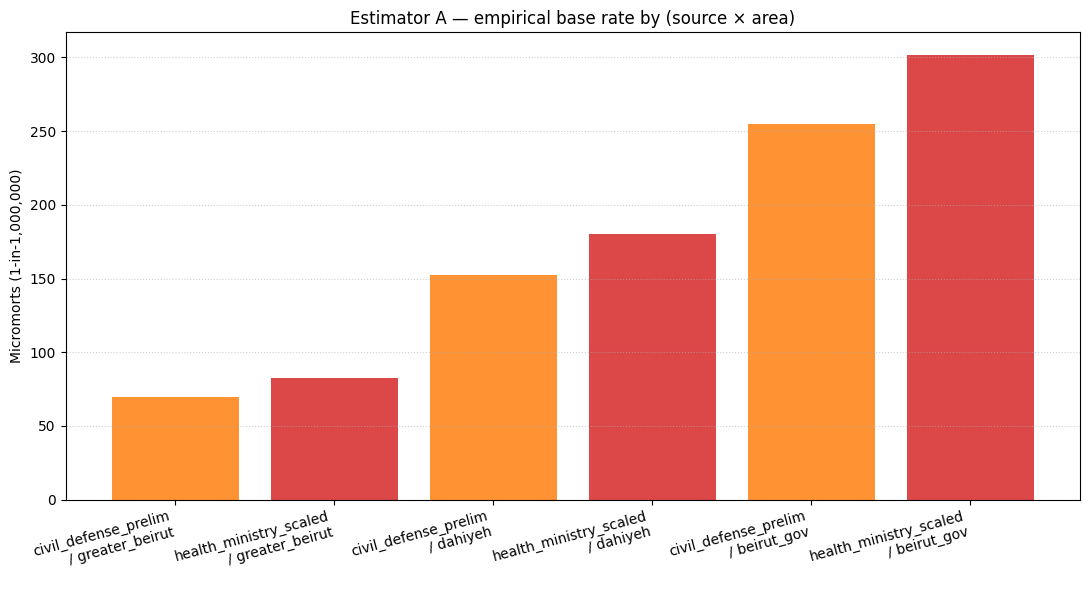

Beirut range (point estimates) :   69.5 – 301.9 µM

--- Metro-vs-metro (consistent denominators, recommended lead) ---
Greater Beirut (HM-scaled) : 82.3 µM  (≈ 1 in 12,155)

--- City-proper (most aggressive matched pair, sensitivity to scaling) ---
Beirut gov (HM-scaled POINT) : 301.9 µM  (1 in 3,312)
Beirut gov (CD UNSCALED)     : 254.8 µM  (1 in 3,924)
The CD-unscaled number is a hard lower bound (direct observation, no scaling).


In [7]:
beirut_rows = est_a[est_a['scope'].isin(['beirut_gov', 'dahiyeh', 'greater_beirut'])].copy()
beirut_rows = beirut_rows.sort_values('micromorts')

fig, ax = plt.subplots(figsize=(11, 6))
labels = [f"{r.source}\n/ {r.scope}" for r in beirut_rows.itertuples()]
colors = ['tab:red' if 'health_ministry' in r.source else 'tab:orange' for r in beirut_rows.itertuples()]
ax.bar(labels, beirut_rows['micromorts'], color=colors, alpha=0.85)
ax.set_ylabel('Micromorts (1-in-1,000,000)')
ax.set_title('Estimator A — empirical base rate by (source × area)')
ax.grid(axis='y', linestyle=':', alpha=0.6)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print(f"Beirut range (point estimates) : {beirut_rows['micromorts'].min():6.1f} – {beirut_rows['micromorts'].max():.1f} µM")
print()
print('--- Metro-vs-metro (consistent denominators, recommended lead) ---')
gb = est_a.query("source=='health_ministry_scaled' and scope=='greater_beirut'").iloc[0]
print(f"Greater Beirut (HM-scaled) : {gb['micromorts']:.1f} µM  (≈ 1 in {1e6/gb['micromorts']:,.0f})")
print()
print('--- City-proper (most aggressive matched pair, sensitivity to scaling) ---')
bg_hm  = est_a.query("source=='health_ministry_scaled' and scope=='beirut_gov'").iloc[0]
bg_cd  = est_a.query("source=='civil_defense_prelim' and scope=='beirut_gov'").iloc[0]
print(f"Beirut gov (HM-scaled POINT) : {bg_hm['micromorts']:.1f} µM  (1 in {1e6/bg_hm['micromorts']:,.0f})")
print(f"Beirut gov (CD UNSCALED)     : {bg_cd['micromorts']:.1f} µM  (1 in {1e6/bg_cd['micromorts']:,.0f})")
print('The CD-unscaled number is a hard lower bound (direct observation, no scaling).')

## Estimator B — strike density + lethal footprint

```
P(death) ≈ 1 − (1 − A_lethal / A_city) ** N_strikes
```

Assumes independent strikes and uniform spatial distribution of both strikes and people. **Both assumptions are wrong** (strikes cluster on targets; people cluster in buildings), so this is a rough upper bound, not a prediction.

In [8]:
def estimator_b(n_strikes, a_lethal_km2, a_city_km2):
    p_miss_single = 1 - a_lethal_km2 / a_city_km2
    return 1 - p_miss_single ** n_strikes

rows = []
for n_label, n in [
    ('low',  strike_counts['beirut_strikes_low']),
    ('mid',  strike_counts['beirut_strikes_mid']),
    ('high', strike_counts['beirut_strikes_high']),
]:
    for a_label, a in [
        ('small_munition', params['a_lethal_km2_low']),
        ('typical',       params['a_lethal_km2_mid']),
        ('large_munition', params['a_lethal_km2_high']),
    ]:
        for scope_name in ['beirut_gov', 'greater_beirut']:
            area = areas_km2[scope_name]
            p = estimator_b(n, a, area)
            rows.append({
                'n_strikes':  f'{n_label}({n})',
                'a_lethal':   a_label,
                'scope':      scope_name,
                'p_death':    p,
                'micromorts': p * 1e6,
            })

est_b = pd.DataFrame(rows)
print(f"Range : {est_b['micromorts'].min():7.2f} – {est_b['micromorts'].max():.2f} µM")
print(f"Median: {est_b['micromorts'].median():7.2f} µM")
est_b.sort_values('micromorts').head(10)

Range :   30.34 – 19447.23 µM
Median:  862.78 µM


,n_strikes,a_lethal,scope,p_death,micromorts
1,low(10),small_munition,greater_beirut,0.00,30.34
7,mid(25),small_munition,greater_beirut,0.00,75.84
3,low(10),typical,greater_beirut,0.00,121.34
13,high(50),small_munition,greater_beirut,0.00,151.68
9,mid(25),typical,greater_beirut,0.00,303.33
5,low(10),large_munition,greater_beirut,0.00,337.03
0,low(10),small_munition,beirut_gov,0.00,353.37
15,high(50),typical,greater_beirut,0.00,606.57
11,mid(25),large_munition,greater_beirut,0.00,842.36
6,mid(25),small_munition,beirut_gov,0.00,883.20


## Estimator C — back-solved per-strike footprint

Invert Estimator B: given observed deaths, what per-strike *effective* footprint would be needed under the uniform-exposure assumption?

**Important interpretation note:** this is **not** a physical blast radius. It's the area that, under Estimator B's uniform-exposure assumption, would have to be lethal to reproduce the observed death count. Comparing it to published single-bomb lethal radii (~15–50 m) quantifies how far from uniform the actual exposure was.

In [9]:
def back_solve_footprint(deaths, population, area_km2, n_strikes):
    # From linearized Estimator B: p = n * a_footprint / area
    # => a_footprint = (deaths/pop) * area / n
    return (deaths / population) * area_km2 / n_strikes

beirut_scopes = ['beirut_gov', 'dahiyeh', 'greater_beirut']
scenarios = []
for _, c in casualties[casualties['scope'].isin(beirut_scopes)].iterrows():
    pop  = populations[c['scope']]
    area = areas_km2[c['scope']]
    for n_label, n in [
        ('low',  strike_counts['beirut_strikes_low']),
        ('mid',  strike_counts['beirut_strikes_mid']),
        ('high', strike_counts['beirut_strikes_high']),
    ]:
        a_eff      = back_solve_footprint(c['killed'], pop, area, n)
        r_equiv_m  = math.sqrt(a_eff / math.pi) * 1000
        scenarios.append({
            'source':    c['source'],
            'scope':     c['scope'],
            'n_strikes': n,
            'per_strike_footprint_km2': a_eff,
            'equivalent_radius_m':      r_equiv_m,
        })

est_c = pd.DataFrame(scenarios)
print('Back-solved per-strike footprint (uniform-exposure equivalent), as an equivalent radius:')
print(f"  range : {est_c['equivalent_radius_m'].min():.1f} – {est_c['equivalent_radius_m'].max():.1f} m")
print(f"  median: {est_c['equivalent_radius_m'].median():.1f} m")
print()
print('This is NOT a physical blast radius. It is the uniform-exposure-equivalent')
print('footprint that would reproduce the observed death count. Real lethal radii')
print('are 15–50 m; the back-solved value being much smaller means the uniform-')
print('exposure model is a poor fit (strikes hit specific buildings, not random ground).')
est_c.head(10)

Back-solved per-strike footprint (uniform-exposure equivalent), as an equivalent radius:
  range : 4.0 – 24.7 m
  median: 9.4 m

This is NOT a physical blast radius. It is the uniform-exposure-equivalent
footprint that would reproduce the observed death count. Real lethal radii
are 15–50 m; the back-solved value being much smaller means the uniform-
exposure model is a poor fit (strikes hit specific buildings, not random ground).


,source,scope,n_strikes,per_strike_footprint_km2,equivalent_radius_m
0,civil_defense_prelim,beirut_gov,10,0.00,12.74
1,civil_defense_prelim,beirut_gov,25,0.00,8.06
2,civil_defense_prelim,beirut_gov,50,0.00,5.70
3,civil_defense_prelim,dahiyeh,10,0.00,9.02
4,civil_defense_prelim,dahiyeh,25,0.00,5.70
5,civil_defense_prelim,dahiyeh,50,0.00,4.03
6,civil_defense_prelim,greater_beirut,10,0.00,22.71
7,civil_defense_prelim,greater_beirut,25,0.00,14.36
8,civil_defense_prelim,greater_beirut,50,0.00,10.16
9,health_ministry_scaled,beirut_gov,10,0.00,13.86


## Estimator D — Monte Carlo uncertainty propagation

All the numbers above are point estimates. The real uncertainty has four sources:

1. **Scaling assumption**: how much of the Health Ministry uplift (46 deaths: 300 − 254) is in Beirut vs elsewhere in Lebanon? Unknown. We use uniform priors over a wide range.
2. **Total uplift**: the HM figure is preliminary and 'still rising'. We allow the uplift to be anywhere in [20, 80] beyond the CD preliminary.
3. **Population uncertainty**: the Beirut governorate figure is cited as either 361k (World Population Review) or 433k (citypopulation.de/Wikipedia). Sampled uniformly. Similarly for Dahiyeh (333k–400k).
4. **Sampling noise**: included but small compared to (1)–(3); observed deaths are essentially a census, not a sample.

Output: **90% credible intervals** on the central estimate for each Beirut scope.

In [10]:
N_SIMS = 200_000
rng = np.random.default_rng(20260408)

# 1. Health Ministry uplift total, allowing for 'still rising' uncertainty.
#    CD = 254, HM = 300+. Uplift is ~46 central, allow [20, 80].
hm_uplift = rng.uniform(20, 80, N_SIMS)

# 2. Fraction of uplift attributable to each Beirut area.
#    Uniform priors span 'none in Beirut' to 'much more than proportional'.
#    Under proportional scaling: Beirut gov frac = 92/254 = 0.362.
bg_frac_uplift = rng.uniform(0.0, 0.6, N_SIMS)
dh_frac_uplift = rng.uniform(0.0, 0.4, N_SIMS)

# 3. Derived deaths (CD direct observation + share of uplift)
bg_deaths = 92 + bg_frac_uplift * hm_uplift
dh_deaths = 61 + dh_frac_uplift * hm_uplift
gb_deaths = bg_deaths + dh_deaths  # Greater Beirut = Beirut gov + Dahiyeh

# 4. Population uncertainty
bg_pop = rng.uniform(361_000, 433_000, N_SIMS)
dh_pop = rng.uniform(333_000, 400_000, N_SIMS)
gb_pop = rng.normal(2_200_000, 150_000, N_SIMS)

# 5. Micromorts
bg_uM = bg_deaths / bg_pop * 1e6
dh_uM = dh_deaths / dh_pop * 1e6
gb_uM = gb_deaths / gb_pop * 1e6

def summarize(name, arr):
    p5, p50, p95 = np.percentile(arr, [5, 50, 95])
    return {'area': name, 'median': p50, 'ci_lower': p5, 'ci_upper': p95}

mc_summary = pd.DataFrame([
    summarize('Greater Beirut metro', gb_uM),
    summarize('Beirut governorate',   bg_uM),
    summarize('Dahiyeh',              dh_uM),
])
print('Monte Carlo 90% credible intervals (N = 200,000):')
print()
for _, row in mc_summary.iterrows():
    print(f"  {row['area']:22s}: median {row['median']:6.1f} µM   90% CI [{row['ci_lower']:6.1f}, {row['ci_upper']:6.1f}]")
print()
print('Widths reflect honest uncertainty about: scaling assumption, population')
print('denominator choice, and preliminary-data revision. The CD-only (no scaling)')
print('lower bound is included because the uplift prior includes zero-Beirut-share.')

Monte Carlo 90% credible intervals (N = 200,000):

  Greater Beirut metro  : median   80.4 µM   90% CI [  69.0,   96.8]
  Beirut governorate    : median  266.0 µM   90% CI [ 227.5,  326.9]
  Dahiyeh               : median  191.2 µM   90% CI [ 163.4,  235.2]

Widths reflect honest uncertainty about: scaling assumption, population
denominator choice, and preliminary-data revision. The CD-only (no scaling)
lower bound is included because the uplift prior includes zero-Beirut-share.


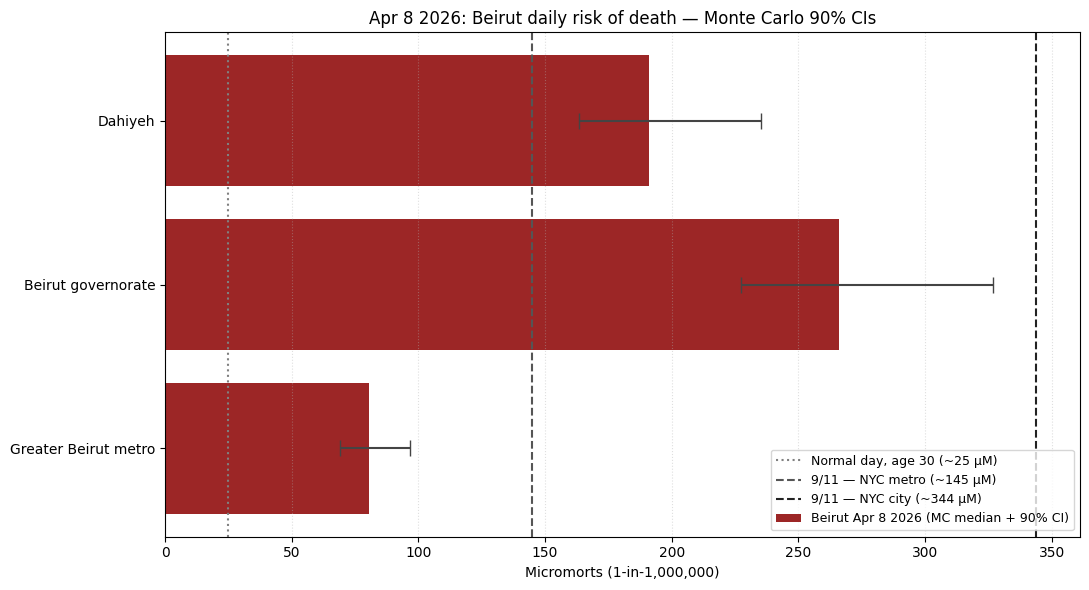

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))
areas    = [r['area'] for _, r in mc_summary.iterrows()]
medians  = [r['median'] for _, r in mc_summary.iterrows()]
lowers   = [r['median'] - r['ci_lower'] for _, r in mc_summary.iterrows()]
uppers   = [r['ci_upper'] - r['median'] for _, r in mc_summary.iterrows()]

ax.barh(areas, medians, xerr=[lowers, uppers], color='#8b0000', alpha=0.85,
        ecolor='#444', capsize=6, label='Beirut Apr 8 2026 (MC median + 90% CI)')
ax.axvline(25, color='gray', linestyle=':', label='Normal day, age 30 (~25 µM)')
ax.axvline(145, color='#555', linestyle='--', label='9/11 — NYC metro (~145 µM)')
ax.axvline(344, color='#222', linestyle='--', label='9/11 — NYC city (~344 µM)')
ax.set_xlabel('Micromorts (1-in-1,000,000)')
ax.set_title('Apr 8 2026: Beirut daily risk of death — Monte Carlo 90% CIs')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

## Comparison to other reference events

All events computed identically: deaths ÷ population most exposed × 1,000,000.

**Corrections vs earlier drafts:**
- **9/11 numerator is 2,753** (NYC-only), not 2,977 (which includes Pentagon + Shanksville). The blog-post headline used 2,977 in earlier drafts; this is the fix.
- **Peak COVID NYC** uses NYC DOH Apr 7 2020 confirmed deaths (598), not an all-inclusive or state-total figure.
- **Beirut port explosion** uses ~220 killed (midpoint of the 218–235 disputed range).
- **Lebanon nationwide population** updated to 5.8M (World Bank 2024).

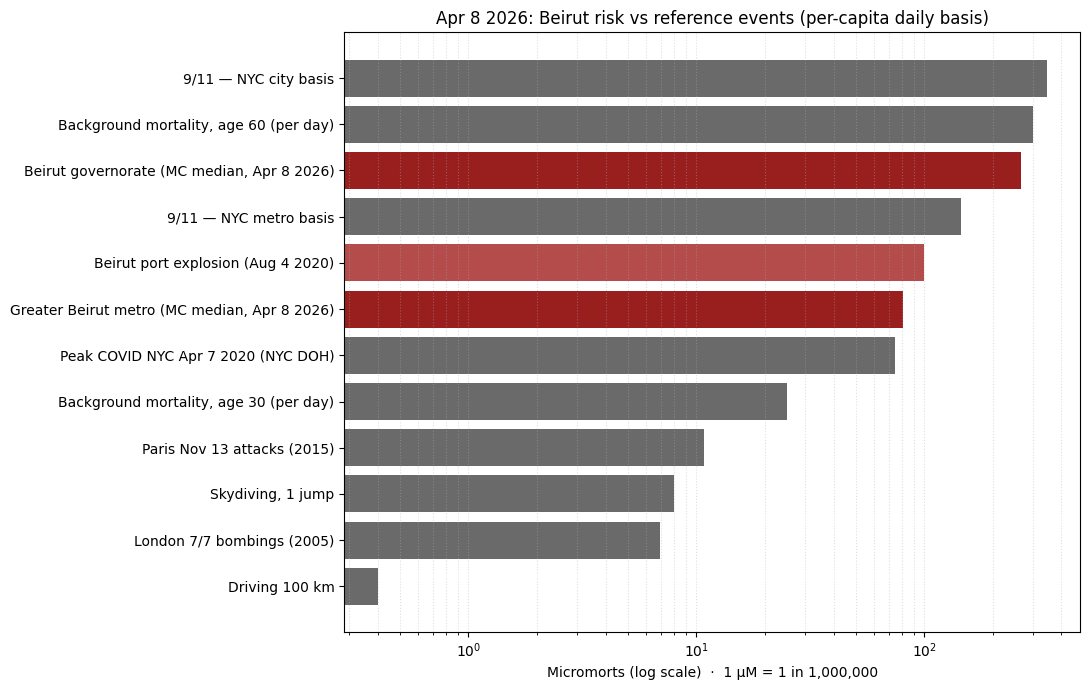


Greater Beirut metro (central)      :   80.4 µM   90% CI [69.0, 96.8]
Beirut governorate (central)        :  266.0 µM   90% CI [227.5, 326.9]

--- Metro-vs-metro comparison (consistent denominator) ---
Greater Beirut Apr 8 2026 : 80 µM  (MC median)
NYC 9/11 metro basis      : 145 µM
Ratio                     : 0.55   (Beirut was ~55% of 9/11 on a metro basis)

--- City-proper comparison ---
Beirut governorate Apr 8  : 266 µM  (MC median)
NYC 9/11 city basis       : 344 µM
Ratio                     : 0.77   (Beirut was ~77% of 9/11 on a city-proper basis)
Beirut gov upper CI       : 327 µM  (~95% of 9/11 city)


In [12]:
baselines = {
    'Driving 100 km':                            0.4,
    'London 7/7 bombings (2005)':                52 / 7_500_000 * 1e6,
    'Skydiving, 1 jump':                         8.0,
    'Paris Nov 13 attacks (2015)':              130 / 12_000_000 * 1e6,
    'Background mortality, age 30 (per day)':   25.0,
    'Peak COVID NYC Apr 7 2020 (NYC DOH)':      598 / 8_000_000 * 1e6,
    'Beirut port explosion (Aug 4 2020)':       220 / 2_200_000 * 1e6,
    '9/11 — NYC metro basis':                  2753 / 19_000_000 * 1e6,
    'Background mortality, age 60 (per day)':  300.0,
    '9/11 — NYC city basis':                   2753 / 8_000_000 * 1e6,
}

# Central estimates from the Monte Carlo
central_gb  = float(np.median(gb_uM))
central_bg  = float(np.median(bg_uM))
central_dh  = float(np.median(dh_uM))
ci_gb_lo    = float(np.percentile(gb_uM, 5))
ci_gb_hi    = float(np.percentile(gb_uM, 95))
ci_bg_lo    = float(np.percentile(bg_uM, 5))
ci_bg_hi    = float(np.percentile(bg_uM, 95))

data = dict(baselines)
data['Greater Beirut metro (MC median, Apr 8 2026)'] = central_gb
data['Beirut governorate (MC median, Apr 8 2026)']   = central_bg

fig, ax = plt.subplots(figsize=(11, 7))
sorted_items = sorted(data.items(), key=lambda x: x[1])
labels = [x[0] for x in sorted_items]
values = [x[1] for x in sorted_items]
colors = ['#8b0000' if ('Beirut' in lbl and '2026' in lbl)
          else '#aa3333' if 'Beirut port' in lbl
          else '#555'
          for lbl in labels]
ax.barh(labels, values, color=colors, alpha=0.88)
ax.set_xscale('log')
ax.set_xlabel('Micromorts (log scale)  ·  1 µM = 1 in 1,000,000')
ax.set_title('Apr 8 2026: Beirut risk vs reference events (per-capita daily basis)')
ax.grid(axis='x', which='both', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

print()
print(f"Greater Beirut metro (central)      : {central_gb:6.1f} µM   90% CI [{ci_gb_lo:.1f}, {ci_gb_hi:.1f}]")
print(f"Beirut governorate (central)        : {central_bg:6.1f} µM   90% CI [{ci_bg_lo:.1f}, {ci_bg_hi:.1f}]")
print()
print('--- Metro-vs-metro comparison (consistent denominator) ---')
nyc_metro_911 = 2753 / 19_000_000 * 1e6
print(f'Greater Beirut Apr 8 2026 : {central_gb:.0f} µM  (MC median)')
print(f'NYC 9/11 metro basis      : {nyc_metro_911:.0f} µM')
print(f'Ratio                     : {central_gb/nyc_metro_911:.2f}   (Beirut was ~{central_gb/nyc_metro_911*100:.0f}% of 9/11 on a metro basis)')
print()
print('--- City-proper comparison ---')
nyc_city_911 = 2753 / 8_000_000 * 1e6
print(f'Beirut governorate Apr 8  : {central_bg:.0f} µM  (MC median)')
print(f'NYC 9/11 city basis       : {nyc_city_911:.0f} µM')
print(f'Ratio                     : {central_bg/nyc_city_911:.2f}   (Beirut was ~{central_bg/nyc_city_911*100:.0f}% of 9/11 on a city-proper basis)')
print(f'Beirut gov upper CI       : {ci_bg_hi:.0f} µM  (~{ci_bg_hi/nyc_city_911*100:.0f}% of 9/11 city)')

## Summary

In [13]:
print('=' * 74)
print(' SUMMARY — Apr 8 2026 Israeli strikes on Lebanon')
print(' Risk of death for an average Beirut resident that day')
print('=' * 74)
print()
print(' Headline (Monte Carlo medians with 90% CIs):')
print()
print(f"   Greater Beirut metro : {central_gb:6.1f} µM  [{ci_gb_lo:6.1f}, {ci_gb_hi:6.1f}]   ≈ 1 in {1e6/central_gb:,.0f}")
print(f"   Beirut governorate   : {central_bg:6.1f} µM  [{ci_bg_lo:6.1f}, {ci_bg_hi:6.1f}]   ≈ 1 in {1e6/central_bg:,.0f}")
print(f"   Dahiyeh (S. suburbs) : {central_dh:6.1f} µM                         ≈ 1 in {1e6/central_dh:,.0f}")
print()
print(' Context — ~25 µM is a normal-day background mortality for a healthy 30-year-old.')
print(' On Apr 8 the daily risk for an average Beirut resident was roughly:')
print(f"   Greater Beirut metro : {central_gb/25:5.1f}x a normal day")
print(f"   Beirut governorate   : {central_bg/25:5.1f}x a normal day")
print(f"   Dahiyeh              : {central_dh/25:5.1f}x a normal day")
print()
print(' Comparison to 9/11 (per-capita, consistent denominator):')
print(f"   Greater Beirut metro / NYC metro 9/11 : {central_gb:.0f} / 145 µM = {central_gb/145:.2f}x")
print(f"   Beirut governorate / NYC city 9/11    : {central_bg:.0f} / 344 µM = {central_bg/344:.2f}x")
print()
print(' *** These are averages over large populations. Residents of directly-hit')
print(' *** blocks faced risks 100–1,000× higher.')
print(' *** Health Ministry says totals are preliminary and expected to rise.')
print(' *** THIS IS A NUMERICAL COMPARISON, NOT A MORAL ONE.')

 SUMMARY — Apr 8 2026 Israeli strikes on Lebanon
 Risk of death for an average Beirut resident that day

 Headline (Monte Carlo medians with 90% CIs):

   Greater Beirut metro :   80.4 µM  [  69.0,   96.8]   ≈ 1 in 12,437
   Beirut governorate   :  266.0 µM  [ 227.5,  326.9]   ≈ 1 in 3,759
   Dahiyeh (S. suburbs) :  191.2 µM                         ≈ 1 in 5,230

 Context — ~25 µM is a normal-day background mortality for a healthy 30-year-old.
 On Apr 8 the daily risk for an average Beirut resident was roughly:
   Greater Beirut metro :   3.2x a normal day
   Beirut governorate   :  10.6x a normal day
   Dahiyeh              :   7.6x a normal day

 Comparison to 9/11 (per-capita, consistent denominator):
   Greater Beirut metro / NYC metro 9/11 : 80 / 145 µM = 0.55x
   Beirut governorate / NYC city 9/11    : 266 / 344 µM = 0.77x

 *** These are averages over large populations. Residents of directly-hit
 *** blocks faced risks 100–1,000× higher.
 *** Health Ministry says totals are preli

## Caveats

1. **Totals still rising.** The Lebanese Ministry of Public Health (authoritative source) says the 300+ figure is preliminary. The Monte Carlo range in Estimator D allows for further upward revision.

2. **Non-uniform targeting.** Strikes cluster in specific neighborhoods. The citywide average hides **orders-of-magnitude variance** between blocks. A resident of a block that took a direct hit faced risks perhaps 100–1,000× higher than the average; a resident of an untargeted neighborhood faced close to a normal day.

3. **Non-uniform exposure.** People shelter, flee, or crowd. The uniform-distribution assumption in Estimator B is wrong; Estimator C quantifies how far off it is.

4. **Scaling assumption.** The `health_ministry_scaled` point estimates apply the Civil Defense preliminary per-district *share* to the Health Ministry nationwide total. If the late-reported bodies are concentrated outside Beirut, the true Beirut count could be as low as the CD observation (92 in Beirut governorate, 255 µM unscaled). The Monte Carlo in Estimator D propagates this uncertainty. The 'Beirut was roughly 9/11-scale per capita' claim survives the full scaling range.

5. **Direct blast only.** Ignores hospital-overload deaths, loss of services, displacement, longer-term health effects, and psychological harm.

6. **One-day window.** Single-day estimates are high-variance. This is *this specific day*, not a war-average.

7. **Dual-use risk.** This analysis can be used honestly to understand scale, or dishonestly to minimize or inflate harm. The repo's openness and explicit uncertainty bounds are the main defense. **This is a numerical comparison, not a moral one** — the fact that two events produce similar per-capita daily-risk numbers says nothing about their causes, contexts, or ethical status.

## Live data fetchers (optional)

In [14]:
import requests

try:
    r = requests.get(
        'https://api.reliefweb.int/v1/reports',
        params={
            'appname':      'estimate-proj-leb',
            'query[value]': 'Lebanon airstrikes April 2026',
            'limit':        5,
            'sort[]':       'date:desc',
            'profile':      'list',
        },
        timeout=10,
    )
    r.raise_for_status()
    data = r.json()
    items = data.get('data', [])
    if not items:
        print('ReliefWeb returned 0 matching reports.')
    for item in items:
        f = item.get('fields', {})
        title = f.get('title', '')
        date  = (f.get('date') or {}).get('created', '')[:10]
        print(f'  {date}  {title}')
except Exception as e:
    print(f'ReliefWeb fetch failed (non-fatal): {e}')

/Users/sherif.maktabi/Documents/Personal Projects/estimate-proj-leb/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


ReliefWeb fetch failed (non-fatal): 410 Client Error: Gone for url: https://api.reliefweb.int/v1/reports?appname=estimate-proj-leb&query%5Bvalue%5D=Lebanon+airstrikes+April+2026&limit=5&sort%5B%5D=date%3Adesc&profile=list


In [15]:
import os

ACLED_KEY   = os.environ.get('ACLED_KEY')
ACLED_EMAIL = os.environ.get('ACLED_EMAIL')

if not (ACLED_KEY and ACLED_EMAIL):
    print('Skipping ACLED fetch — set ACLED_KEY and ACLED_EMAIL env vars.')
else:
    try:
        r = requests.get(
            'https://api.acleddata.com/acled/read',
            params={
                'key':        ACLED_KEY,
                'email':      ACLED_EMAIL,
                'country':    'Lebanon',
                'event_date': '2026-04-08',
                'limit':      200,
            },
            timeout=15,
        )
        r.raise_for_status()
        payload = r.json()
        events  = payload.get('data', [])
        print(f'ACLED events for Lebanon 2026-04-08: {len(events)}')
        if events:
            acled_df = pd.DataFrame(events)
            cols = [c for c in ['event_date', 'event_type', 'location', 'fatalities', 'notes'] if c in acled_df.columns]
            display(acled_df[cols].head(20))
    except Exception as e:
        print(f'ACLED fetch failed (non-fatal): {e}')

Skipping ACLED fetch — set ACLED_KEY and ACLED_EMAIL env vars.


## Sanity checks

In [16]:
assert (casualties['killed']  >= 0).all()
assert (casualties['wounded'] >= 0).all()

# Authoritative-vs-preliminary consistency
assert CD_NATIONWIDE_KILLED <= HM_NATIONWIDE_KILLED, 'HM total should be >= CD preliminary'
print('✓ HM nationwide ≥ CD nationwide (killed)')

# Scope containment (same source)
nationwide = casualties[casualties['scope'] == 'nationwide'].set_index('source')['killed']
beirut_gb  = casualties[casualties['scope'] == 'greater_beirut'].set_index('source')['killed']
assert beirut_gb['civil_defense_prelim']    <= nationwide['civil_defense_prelim']
assert beirut_gb['health_ministry_scaled'] <= nationwide['health_ministry']
print('✓ Greater Beirut deaths ≤ nationwide deaths (same source)')

# Greater Beirut = Beirut gov + Dahiyeh (CD direct)
cd_bg  = casualties.query("source=='civil_defense_prelim' and scope=='beirut_gov'")['killed'].iloc[0]
cd_dh  = casualties.query("source=='civil_defense_prelim' and scope=='dahiyeh'")['killed'].iloc[0]
cd_gb  = casualties.query("source=='civil_defense_prelim' and scope=='greater_beirut'")['killed'].iloc[0]
assert cd_gb == cd_bg + cd_dh, f'greater_beirut ({cd_gb}) should equal beirut_gov + dahiyeh ({cd_bg+cd_dh})'
print(f'✓ Greater Beirut = Beirut gov + Dahiyeh ({cd_gb} = {cd_bg} + {cd_dh})')

# Probabilities in range
assert (est_a['p_death'] >= 0).all() and (est_a['p_death'] <= 1).all()
assert (est_b['p_death'] >= 0).all() and (est_b['p_death'] <= 1).all()
print('✓ All probabilities in [0, 1]')

# Monte Carlo samples are finite and in plausible range
assert (bg_uM > 0).all() and (bg_uM < 1e6).all()
assert (dh_uM > 0).all() and (dh_uM < 1e6).all()
assert (gb_uM > 0).all() and (gb_uM < 1e6).all()
print('✓ All Monte Carlo samples finite and in plausible range')

# MC central estimates should bracket the HM-scaled point estimate
bg_point = est_a.query("source=='health_ministry_scaled' and scope=='beirut_gov'").iloc[0]['micromorts']
gb_point = est_a.query("source=='health_ministry_scaled' and scope=='greater_beirut'").iloc[0]['micromorts']
assert abs(np.median(bg_uM) - bg_point) < 80, f'MC median {np.median(bg_uM):.1f} far from point estimate {bg_point:.1f}'
assert abs(np.median(gb_uM) - gb_point) < 20, f'MC median {np.median(gb_uM):.1f} far from point estimate {gb_point:.1f}'
print(f'✓ MC medians bracket HM-scaled point estimates')

# Reasonable CI widths (catches runaway priors)
gb_ci_width = np.percentile(gb_uM, 95) - np.percentile(gb_uM, 5)
assert 15 < gb_ci_width < 60, f'Greater Beirut CI width {gb_ci_width:.1f} looks off'
print(f'✓ Greater Beirut 90% CI width = {gb_ci_width:.1f} µM (reasonable)')

# Verify the corrected 9/11 numbers
expected_911_city  = 2753 / 8_000_000  * 1e6
expected_911_metro = 2753 / 19_000_000 * 1e6
assert abs(baselines['9/11 — NYC city basis']  - expected_911_city)  < 0.5
assert abs(baselines['9/11 — NYC metro basis'] - expected_911_metro) < 0.5
print(f'✓ 9/11 numerator corrected: NYC city {expected_911_city:.1f} µM, NYC metro {expected_911_metro:.1f} µM')

print()
print('✓ All sanity checks passed.')

✓ HM nationwide ≥ CD nationwide (killed)
✓ Greater Beirut deaths ≤ nationwide deaths (same source)
✓ Greater Beirut = Beirut gov + Dahiyeh (153 = 92 + 61)
✓ All probabilities in [0, 1]
✓ All Monte Carlo samples finite and in plausible range
✓ MC medians bracket HM-scaled point estimates
✓ Greater Beirut 90% CI width = 27.8 µM (reasonable)
✓ 9/11 numerator corrected: NYC city 344.1 µM, NYC metro 144.9 µM

✓ All sanity checks passed.
